# *Data Describtion*



In [21]:
import pandas as pd
from autoimpute.imputations import SingleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, f1_score, recall_score,
    precision_score, roc_auc_score, accuracy_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from skrebate import ReliefF
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

In [22]:
df=pd.read_csv("Telco_Churn_Data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,NaN,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,NaN,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7093 entries, 0 to 7092
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7093 non-null   object 
 1   gender            7093 non-null   object 
 2   SeniorCitizen     7093 non-null   int64  
 3   Partner           7093 non-null   object 
 4   Dependents        7093 non-null   object 
 5   tenure            7073 non-null   float64
 6   PhoneService      6940 non-null   object 
 7   MultipleLines     6927 non-null   object 
 8   InternetService   7093 non-null   object 
 9   OnlineSecurity    6951 non-null   object 
 10  OnlineBackup      6949 non-null   object 
 11  DeviceProtection  7093 non-null   object 
 12  TechSupport       6940 non-null   object 
 13  StreamingTV       7093 non-null   object 
 14  StreamingMovies   7093 non-null   object 
 15  Contract          7078 non-null   object 
 16  PaperlessBilling  6957 non-null   object 


C:\Users\PC\AppData\Local\Temp\ipykernel_16428\3146081353.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


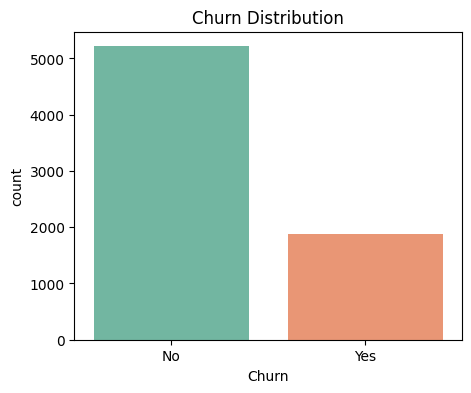

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Churn Distribution
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title("Churn Distribution")
plt.show()
# After excuting the above code, we can see that the dataset is imbalanced, with more non-churned customers than churned ones. 
# This imbalance can affect the performance of our predictive model, so we may need to consider techniques such as:
#   resampling (oversampling the minority class or undersampling the majority class) to address this issue before training our model.

# Data Cleaning


In [25]:
# remove CustomerID column
df.drop('customerID', axis=1, inplace=True) # because it is not useful for prediction

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_report = pd.DataFrame({
'Missing Count' : missing,
'Missing %'     : missing_pct
}).query('`Missing Count` > 0')

print("Missing Values:")
print(quality_report.to_string())
print(f"Duplicate rows: {df.duplicated().sum()}")

Missing Values:
                  Missing Count  Missing %
tenure                       20       0.28
PhoneService                153       2.16
MultipleLines               166       2.34
OnlineSecurity              142       2.00
OnlineBackup                144       2.03
TechSupport                 153       2.16
Contract                     15       0.21
PaperlessBilling            136       1.92
PaymentMethod               153       2.16
MonthlyCharges              172       2.42
TotalCharges                151       2.13
Duplicate rows: 42


## *Remove duplicated values*

In [26]:
before = len(df)
df.drop_duplicates(inplace=True)
after  = len(df)

print(f"Rows before : {before}")
print(f"Rows removed: {before - after}")
print(f"Rows after  : {after}")

Rows before : 7093
Rows removed: 42
Rows after  : 7051


## *convert type of TotalCharges*



In [27]:
# type corrections
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7051 entries, 0 to 7092
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7051 non-null   object 
 1   SeniorCitizen     7051 non-null   int64  
 2   Partner           7051 non-null   object 
 3   Dependents        7051 non-null   object 
 4   tenure            7031 non-null   float64
 5   PhoneService      6898 non-null   object 
 6   MultipleLines     6885 non-null   object 
 7   InternetService   7051 non-null   object 
 8   OnlineSecurity    6909 non-null   object 
 9   OnlineBackup      6907 non-null   object 
 10  DeviceProtection  7051 non-null   object 
 11  TechSupport       6898 non-null   object 
 12  StreamingTV       7051 non-null   object 
 13  StreamingMovies   7051 non-null   object 
 14  Contract          7036 non-null   object 
 15  PaperlessBilling  6915 non-null   object 
 16  PaymentMethod     6898 non-null   object 
 17  

In [28]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' nan 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes' nan]
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service' nan]
OnlineBackup: ['Yes' 'No' 'No internet service' nan]
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service' nan]
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year' nan]
PaperlessBilling: ['Yes' 'No' nan]
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)' nan]
Churn: ['No' 'Yes']


## *Replace inconsistent values in some columns*


In [29]:
df.replace('No internet service', 'No', inplace=True)
df['PaymentMethod'] = df['PaymentMethod'].str.replace(r'\s*\(automatic\)', '', regex=True)
df['Contract'] = df['Contract'].replace('Month-to-month', 'Monthly')
df['MultipleLines']=df['MultipleLines'].replace('No phone service', 'No')

for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' nan 'Yes']
MultipleLines: ['No' 'Yes' nan]
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' nan]
OnlineBackup: ['Yes' 'No' nan]
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes' nan]
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']
Contract: ['Monthly' 'One year' 'Two year' nan]
PaperlessBilling: ['Yes' 'No' nan]
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer' 'Credit card' nan]
Churn: ['No' 'Yes']


## *Handle missing values*

In [30]:
missing_columns_category = [col for col in quality_report.index if df[col].dtype == 'object']

strategy_dict = {col: 'mode' for col in missing_columns_category}
df[missing_columns_category] = SingleImputer(
    strategy=strategy_dict,
    seed=42
).fit_transform(df[missing_columns_category])


df['MonthlyCharges'] = df.groupby('InternetService')['MonthlyCharges'].transform(lambda x: x.fillna(x.median()))
df['tenure'] = df.groupby('Contract')['tenure'].transform(lambda x: x.fillna(x.median()))
df['tenure'] = df['tenure'].round().astype(int)
mask_tc = df['TotalCharges'].isnull() & (df['tenure'] == 0)
df.loc[mask_tc, 'TotalCharges'] = df.loc[mask_tc, 'MonthlyCharges']

df['TotalCharges'] = df['TotalCharges'].fillna(
    df['tenure'] * df['MonthlyCharges'])

print("Number of missing values:\n", df.isnull().sum())
df.head()


Number of missing values:
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Monthly,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Monthly,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Bank transfer,42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Monthly,Yes,Electronic check,70.70,151.65,Yes


In [31]:
pivot = pd.pivot_table(
df,
values   = 'MonthlyCharges',
index    = 'Contract',
columns  = 'InternetService',
aggfunc  = 'mean'
).round(2)

print("Average Monthly Charges by Contract x Internet Service:")
print(pivot.head())

# Churn Rate per Contract type
churn_pivot = pd.pivot_table(
df,
values  = 'Churn',
index   = 'Contract',
aggfunc = lambda x: (x == 'Yes').sum() / len(x) * 100
).round(2)
churn_pivot.columns = ['Churn Rate %']
print(r"\nChurn Rate % by Contract Type:")
print(churn_pivot.head())

Average Monthly Charges by Contract x Internet Service:
InternetService    DSL  Fiber optic     No
Contract                                  
Monthly          50.45        87.21  20.38
One year         61.28        98.58  20.77
Two year         70.05       104.30  21.73
\nChurn Rate % by Contract Type:
          Churn Rate %
Contract              
Monthly          42.59
One year         11.07
Two year          2.83


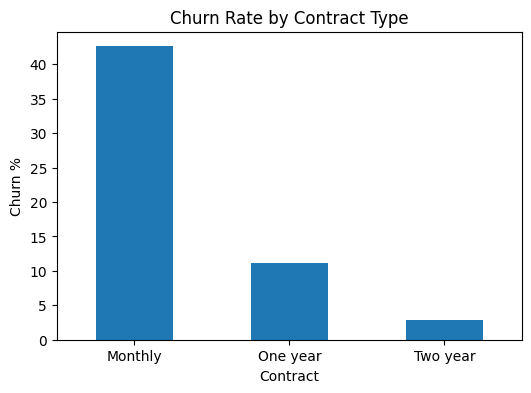

In [32]:
churn_pivot.plot(kind='bar', figsize=(6,4), legend=False)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn %")
plt.xticks(rotation=0)
plt.show()
# After excuting the above code, we can see that customers with month-to-month contracts have a significantly higher churn rate compared to those with one-year or two-year contracts. 
# This suggests that customers on shorter-term contracts may be more likely to leave, possibly due to less commitment or satisfaction. 
# This insight can help the company focus retention efforts on customers with month-to-month contracts.

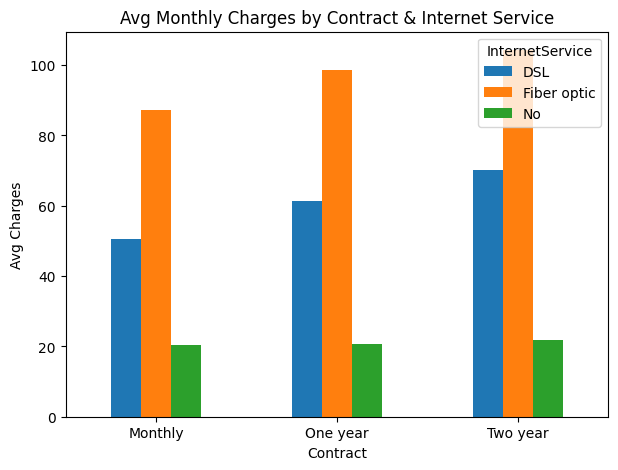

In [33]:
pivot.plot(kind='bar', figsize=(7,5))
plt.title("Avg Monthly Charges by Contract & Internet Service")
plt.ylabel("Avg Charges")
plt.xticks(rotation=0)
plt.show()
# After excuting the above code, we can see that customers with fiber optic internet service have higher average monthly charges compared to those with DSL or no internet service. 
# Additionally, customers with month-to-month contracts tend to have higher average monthly charges than those with longer-term contracts, especially for fiber optic service.

In [34]:
import os
DATA_DIR = "data"
dataset_path = os.path.join(DATA_DIR, "final_dataset_clean.csv")
if not os.path.exists(dataset_path):
    df.to_csv(dataset_path, index=False)
    print(f"Saved: {dataset_path}")
else:
    print(f"Already exists: {dataset_path}")

Already exists: data\final_dataset_clean.csv


# *Encoding*

In [35]:
# Binary
binary_cols = [col for col in df.columns if df[col].nunique() == 2 and df[col].dtype == 'object']
for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0, 'Male':1, 'Female':0})
# Ordinal data
df['Contract'] = df['Contract'].map({
    'Monthly': 0,
    'One year': 1,
    'Two year': 2
})

# One Hot
df= pd.get_dummies(df, columns=[
    'InternetService',
    'PaymentMethod',
    'MultipleLines'
],dtype=int)


df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_0,MultipleLines_1
0,0,0,1,0,1,0,0,1,0,0,...,0,1,0,0,0,0,1,0,1,0
1,1,0,0,0,34,1,1,0,1,0,...,0,1,0,0,0,0,0,1,1,0
2,1,0,0,0,2,1,1,1,0,0,...,1,1,0,0,0,0,0,1,1,0
3,1,0,0,0,45,0,1,0,1,1,...,0,1,0,0,1,0,0,0,1,0
4,0,0,0,0,2,1,0,0,0,0,...,1,0,1,0,0,0,1,0,1,0


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7051 entries, 0 to 7092
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   gender                          7051 non-null   int64  
 1   SeniorCitizen                   7051 non-null   int64  
 2   Partner                         7051 non-null   int64  
 3   Dependents                      7051 non-null   int64  
 4   tenure                          7051 non-null   int64  
 5   PhoneService                    7051 non-null   int64  
 6   OnlineSecurity                  7051 non-null   int64  
 7   OnlineBackup                    7051 non-null   int64  
 8   DeviceProtection                7051 non-null   int64  
 9   TechSupport                     7051 non-null   int64  
 10  StreamingTV                     7051 non-null   int64  
 11  StreamingMovies                 7051 non-null   int64  
 12  Contract                        7051 no

# Feature Extraction

In [37]:
service_cols = [
    'PhoneService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

df['TotalServices'] = df[service_cols].sum(axis=1)
print(df[['TotalServices']].head())

   TotalServices
0              1
1              3
2              3
3              3
4              1


C:\Users\PC\AppData\Local\Temp\ipykernel_16428\2381507891.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='TotalServices', data=df, palette='Set2')


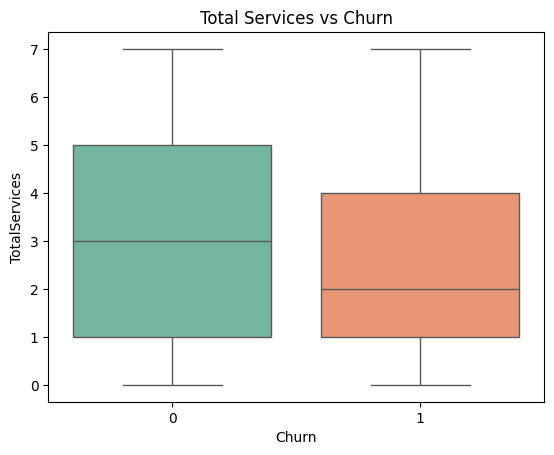

In [38]:
sns.boxplot(x='Churn', y='TotalServices', data=df, palette='Set2')
plt.title("Total Services vs Churn")
plt.show()
# After excuting the above code, we can see that customers who churn tend to have fewer total services compared to those who do not churn. 
# This suggests that customers with more services may be more satisfied or engaged, and therefore less likely to churn.

In [39]:
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)
print(df[['AvgMonthlySpend']].head())

   AvgMonthlySpend
0        14.925000
1        53.985714
2        36.050000
3        40.016304
4        50.550000


C:\Users\PC\AppData\Local\Temp\ipykernel_16428\3538562926.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='AvgMonthlySpend', data=df, palette='Set2', showfliers=False)


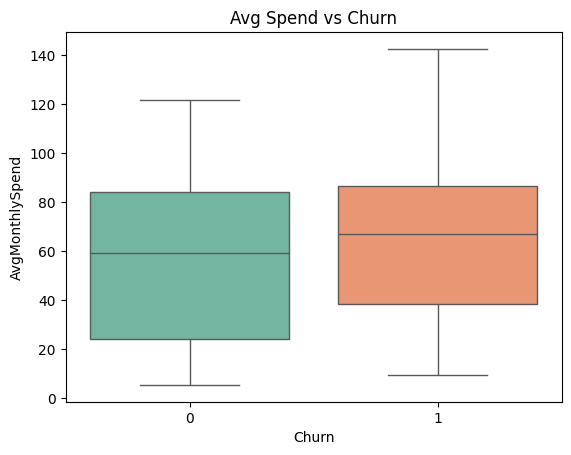

In [40]:
sns.boxplot(x='Churn', y='AvgMonthlySpend', data=df, palette='Set2', showfliers=False)
plt.title("Avg Spend vs Churn")
plt.show()
# After excuting the above code, we can see that customers who churn tend to have a higher average monthly spend compared to those who do not churn. 
# This could indicate that customers who are paying more on average may have higher expectations and may be more likely to leave if they are not satisfied with the service.

In [41]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 36, 100],
    labels=[0, 1, 2]
).astype(int)
print(df[['TenureGroup']].head())

   TenureGroup
0            0
1            1
2            0
3            2
4            0


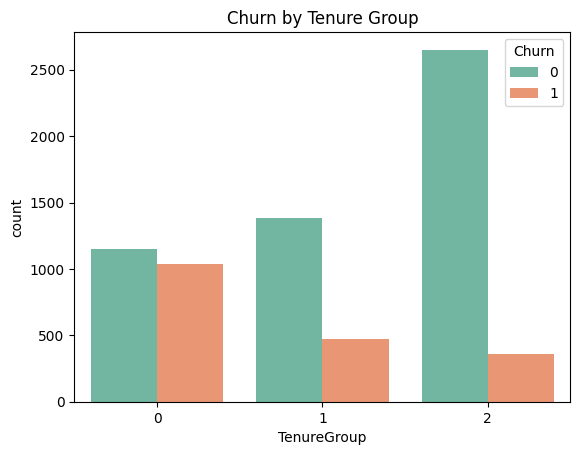

In [42]:
sns.countplot(x='TenureGroup', hue='Churn', data=df, palette='Set2')
plt.title("Churn by Tenure Group")
plt.show()
# After excuting the above code, we can see that customers in the lowest tenure group (0-12 months) have a much higher churn rate compared to those in the middle (13-36 months) and high (37+ months) tenure groups.
# This suggests that new customers are more likely to churn, and retention efforts should focus on engaging and satisfying customers during their first year of service.

In [43]:
df['HighValueCustomer'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)
print(df[['HighValueCustomer']].head())

   HighValueCustomer
0                  0
1                  0
2                  0
3                  0
4                  1


In [44]:
df['ContractRisk'] = df['Contract'].apply(lambda x: 2 if x == 0 else (1 if x == 1 else 0))
print(df[['ContractRisk']].head())

   ContractRisk
0             2
1             1
2             2
3             1
4             2


In [45]:
df['Charge_Tenure_Interaction'] = df['MonthlyCharges'] * df['tenure']
print(df[['Charge_Tenure_Interaction']].head())

   Charge_Tenure_Interaction
0                      29.85
1                    1936.30
2                     107.70
3                    1903.50
4                     141.40


In [46]:
df['MonthlyToTotalRatio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)
print(df[['MonthlyToTotalRatio']].head())

   MonthlyToTotalRatio
0             0.967585
1             0.030124
2             0.493358
3             0.022967
4             0.463151


In [47]:
df['ExpectedVsActualCharges'] = df['MonthlyCharges'] * df['tenure'] - df['TotalCharges']

print(df[['ExpectedVsActualCharges']].head())

   ExpectedVsActualCharges
0                     0.00
1                    46.80
2                    -0.45
3                    62.75
4                   -10.25


In [48]:
df['ServiceEfficiency'] = df['TotalCharges'] / (df['TotalServices'] + 1)

print(df[['ServiceEfficiency']].head())

   ServiceEfficiency
0            14.9250
1           472.3750
2            27.0375
3           460.1875
4            75.8250


In [49]:
X = df.drop('Churn', axis=1)
y = df['Churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2','PC3','PC4','PC5','PC6','PC7','PC8','PC9','PC10'])

pca_df['Churn'] = y.values

pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Churn
0,-4.067291,-1.091329,2.760688,-1.931797,-0.324586,-0.061495,1.601608,-0.067555,0.451697,-0.992359,0
1,-1.259262,1.568334,1.650517,0.925995,0.751436,0.641424,-0.925638,-1.145090,0.315017,1.329804,0
2,-3.158335,-0.708632,2.425318,1.198586,0.834851,1.136160,-0.256793,-0.038519,0.178963,1.483559,1
3,-0.382637,2.310418,3.152262,-2.168002,-0.127618,1.601629,-1.184958,0.352916,-0.317753,0.984666,0
4,-2.646420,-3.233698,-0.345485,-0.126021,-0.504213,-0.745772,-0.567935,0.271301,0.204964,-1.088969,1


In [50]:
print(f"Total Variance Explained: {sum(pca.explained_variance_ratio_) * 100:.2f}%")

Total Variance Explained: 75.31%


In [51]:
X = df.drop('Churn', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['CustomerCluster'] = kmeans.fit_predict(X_scaled)

df[['CustomerCluster']].head(5)

,CustomerCluster
0,1
1,1
2,1
3,1
4,0


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7051 entries, 0 to 7092
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   gender                          7051 non-null   int64  
 1   SeniorCitizen                   7051 non-null   int64  
 2   Partner                         7051 non-null   int64  
 3   Dependents                      7051 non-null   int64  
 4   tenure                          7051 non-null   int64  
 5   PhoneService                    7051 non-null   int64  
 6   OnlineSecurity                  7051 non-null   int64  
 7   OnlineBackup                    7051 non-null   int64  
 8   DeviceProtection                7051 non-null   int64  
 9   TechSupport                     7051 non-null   int64  
 10  StreamingTV                     7051 non-null   int64  
 11  StreamingMovies                 7051 non-null   int64  
 12  Contract                        7051 no

# Feature Selection

In [53]:
X = df.drop('Churn', axis=1)
y = df['Churn']
# Train & Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# METHOD 1: FILTER METHODS (Mutual Info)

In [54]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [55]:
# Mutual Information
mi_selector = SelectKBest(score_func=mutual_info_classif, k=10)
mi_selector.fit(X_train, y_train)

mi_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': mi_selector.scores_
}).sort_values(by='Score', ascending=False)

print("Mutual Information Top Features:")
print(mi_scores.head(10))

mi_features = X_train.columns[mi_selector.get_support()]

Mutual Information Top Features:
                           Feature     Score
29                    ContractRisk  0.099716
12                        Contract  0.097503
31             MonthlyToTotalRatio  0.076737
34                 CustomerCluster  0.071548
4                           tenure  0.070769
30       Charge_Tenure_Interaction  0.057091
27                     TenureGroup  0.053503
33               ServiceEfficiency  0.052799
21  PaymentMethod_Electronic check  0.050277
17     InternetService_Fiber optic  0.046749


# Method 2 Embedded Method (random forest)

In [56]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'RF_Importance': rf.feature_importances_
}).sort_values('RF_Importance', ascending=False)

rf_features = list(rf_scores.head(10)['Feature'])

print("=== Random Forest Importance — Top 10 Features ===")
print(rf_scores.head(10).to_string(index=False))
print(f"\nSelected: {rf_features}")

=== Random Forest Importance — Top 10 Features ===
                  Feature  RF_Importance
      MonthlyToTotalRatio       0.097514
           MonthlyCharges       0.083914
          AvgMonthlySpend       0.077950
        ServiceEfficiency       0.077943
             TotalCharges       0.075113
Charge_Tenure_Interaction       0.074939
  ExpectedVsActualCharges       0.063390
                   tenure       0.060513
          CustomerCluster       0.039410
             ContractRisk       0.037190

Selected: ['MonthlyToTotalRatio', 'MonthlyCharges', 'AvgMonthlySpend', 'ServiceEfficiency', 'TotalCharges', 'Charge_Tenure_Interaction', 'ExpectedVsActualCharges', 'tenure', 'CustomerCluster', 'ContractRisk']


C:\Users\PC\AppData\Local\Temp\ipykernel_16428\1016084049.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RF_Importance', y='Feature', data=rf_scores.head(10), palette='Set2')


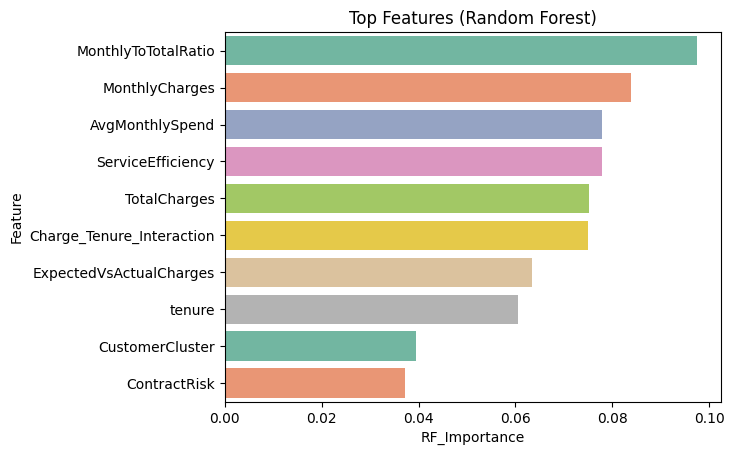

In [57]:
sns.barplot(x='RF_Importance', y='Feature', data=rf_scores.head(10), palette='Set2')
plt.title("Top Features (Random Forest)")
plt.show()
# After excuting the above code, we can see the top 10 features based on Random Forest importance scores.
# These features are likely to be the most influential in predicting customer churn, and can be used to build a more focused and interpretable model.

# Method 3 Reliff (Filter Method)

In [58]:
relieff = ReliefF(n_features_to_select=15, n_neighbors=100, n_jobs=-1)
relieff.fit(X_train.values, y_train.values)

relieff_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'ReliefF_Score': relieff.feature_importances_
}).sort_values('ReliefF_Score', ascending=False)

relieff_features = list(X_train.columns[relieff.top_features_[:10]])

print("=== ReliefF — Top 10 Features ===")
print(relieff_scores.head(10).to_string(index=False))
print(f"\nSelected: {relieff_features}")

=== ReliefF — Top 10 Features ===
                       Feature  ReliefF_Score
                      Contract       0.206610
                  ContractRisk       0.206610
                   TenureGroup       0.140172
           MonthlyToTotalRatio       0.130578
                        tenure       0.114371
             ServiceEfficiency       0.105022
           InternetService_DSL       0.088367
   InternetService_Fiber optic       0.065289
PaymentMethod_Electronic check       0.064089
     Charge_Tenure_Interaction       0.059030

Selected: ['ContractRisk', 'Contract', 'TenureGroup', 'MonthlyToTotalRatio', 'tenure', 'ServiceEfficiency', 'InternetService_DSL', 'InternetService_Fiber optic', 'PaymentMethod_Electronic check', 'Charge_Tenure_Interaction']


# Method 4 Backword Elimination

In [59]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler_rfe = StandardScaler()
X_train_sc_rfe = scaler_rfe.fit_transform(X_train)

lr_rfe = LogisticRegression(max_iter=5000, solver='saga', random_state=42)
rfe = RFE(estimator=lr_rfe, n_features_to_select=10, step=1)
rfe.fit(X_train_sc_rfe, y_train)

rfe_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'RFE_Rank': rfe.ranking_   # rank=1 يعني selected
}).sort_values('RFE_Rank')

backward_features = list(X_train.columns[rfe.support_])

print("=== Backward Elimination (RFE) — Selected Features ===")
print(rfe_scores[rfe_scores['RFE_Rank'] == 1].to_string(index=False))
print(f"\nSelected: {backward_features}")

=== Backward Elimination (RFE) — Selected Features ===
                    Feature  RFE_Rank
                     tenure         1
           PaperlessBilling         1
                StreamingTV         1
            StreamingMovies         1
                   Contract         1
               ContractRisk         1
         InternetService_No         1
InternetService_Fiber optic         1
            AvgMonthlySpend         1
        MonthlyToTotalRatio         1

Selected: ['tenure', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'InternetService_Fiber optic', 'InternetService_No', 'AvgMonthlySpend', 'ContractRisk', 'MonthlyToTotalRatio']


# Compare Between Features Selection Methods

In [60]:
feature_sets = {
    'Mutual Information': mi_features,
    'Random Forest':      rf_features,
    'ReliefF':            relieff_features,
    'Backward (RFE)':     backward_features,
}

comparison_results = {}

for method_name, feats in feature_sets.items():
    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train[feats])
    X_te_sc = scaler.transform(X_test[feats])

    model = LogisticRegression(max_iter=5000, solver='saga', random_state=42)
    model.fit(X_tr_sc, y_train)

    y_pred  = model.predict(X_te_sc)
    y_proba = model.predict_proba(X_te_sc)[:, 1]

    comparison_results[method_name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1 Score':  round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba), 4),
        'Num Features': len(feats),
        'features':  feats,
        'scaler':    scaler,
        'model':     model,
    }

    print(f"\n{'='*55}")
    print(f"  {method_name}  ({len(feats)} features)")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    print(f"ROC-AUC: {comparison_results[method_name]['ROC-AUC']}")


  Mutual Information  (10 features)
              precision    recall  f1-score   support

    No Churn       0.82      0.92      0.87      1557
       Churn       0.66      0.45      0.54       559

    accuracy                           0.79      2116
   macro avg       0.74      0.68      0.70      2116
weighted avg       0.78      0.79      0.78      2116

ROC-AUC: 0.8452

  Random Forest  (10 features)
              precision    recall  f1-score   support

    No Churn       0.82      0.92      0.87      1557
       Churn       0.67      0.46      0.54       559

    accuracy                           0.80      2116
   macro avg       0.75      0.69      0.71      2116
weighted avg       0.78      0.80      0.78      2116

ROC-AUC: 0.8452

  ReliefF  (10 features)
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1557
       Churn       0.66      0.47      0.55       559

    accuracy                           0.79      2116
 

=== Feature Selection Methods — Performance Summary ===
                   Accuracy Precision  Recall F1 Score ROC-AUC Num Features
Mutual Information   0.7935    0.6597  0.4508   0.5356  0.8452           10
Random Forest        0.7977    0.6728  0.4562   0.5437  0.8452           10
ReliefF              0.7949    0.6551  0.4723   0.5489  0.8501           10
Backward (RFE)       0.8058    0.6859  0.4884   0.5705  0.8496           10


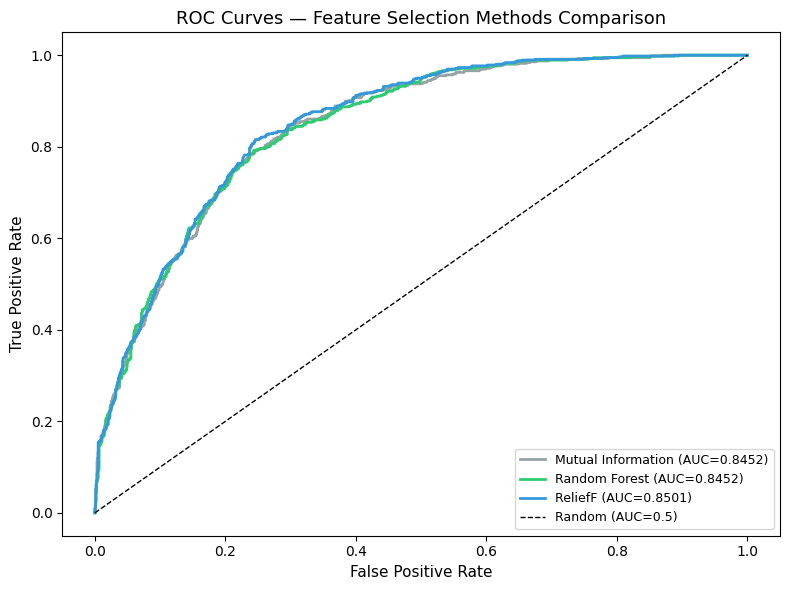

In [61]:
summary_df = pd.DataFrame(comparison_results).T.drop(columns=['features', 'scaler', 'model'])
print("=== Feature Selection Methods — Performance Summary ===")
print(summary_df.to_string())

colors  = ['#95a5a6', '#2ecc71', '#3498db']
fig, ax = plt.subplots(figsize=(8, 6))
for (method_name, res), color in zip(comparison_results.items(), colors):
    feats  = res['features']
    scaler = res['scaler']
    model  = res['model']
    X_te_sc = scaler.transform(X_test[feats])
    y_proba = model.predict_proba(X_te_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{method_name} (AUC={res["ROC-AUC"]})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — Feature Selection Methods Comparison', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

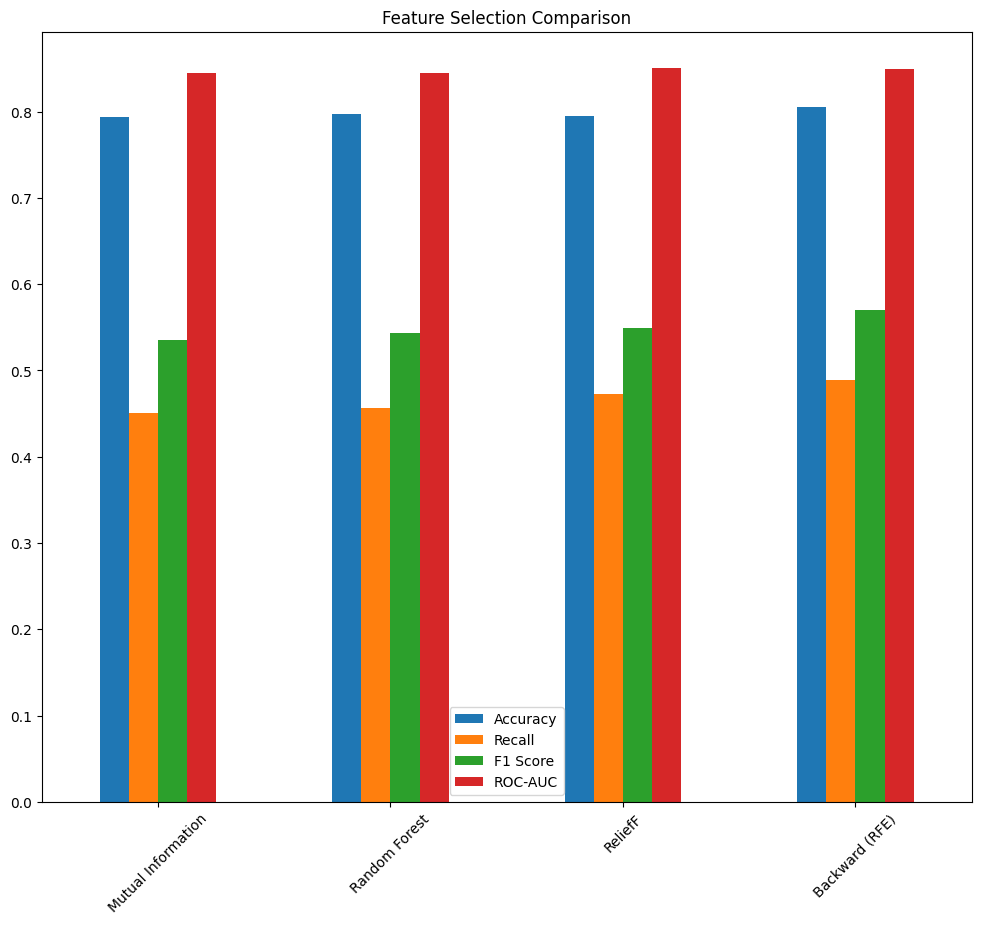

In [62]:
summary_df[['Accuracy','Recall','F1 Score','ROC-AUC']].plot(kind='bar', figsize=(12,10))
plt.title("Feature Selection Comparison")
plt.xticks(rotation=45)
plt.show()
# After excuting the above code, we can see the performance comparison of different feature selection methods based on metrics like Accuracy, Recall, F1 Score, and ROC-AUC.
# This visualization helps us understand which feature selection method led to the best predictive performance for our churn model, and can guide us in choosing the most effective features for deployment.

# Best Method accuracy

In [63]:
best_method = max(comparison_results, key=lambda m: comparison_results[m]['Accuracy'])
best_features = comparison_results[best_method]['features']

print(f" Best Feature Selection Method: {best_method}")
print(f"   Accuracy : {comparison_results[best_method]['Accuracy']}")
print(f"   ROC-AUC  : {comparison_results[best_method]['ROC-AUC']}")
print(f"   Features ({len(best_features)}): {best_features}")

X_train_best = X_train[best_features]
X_test_best  = X_test[best_features]

 Best Feature Selection Method: Backward (RFE)
   Accuracy : 0.8058
   ROC-AUC  : 0.8496
   Features (10): ['tenure', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'InternetService_Fiber optic', 'InternetService_No', 'AvgMonthlySpend', 'ContractRisk', 'MonthlyToTotalRatio']


#  Data Imbalance Handling

In [64]:
print('Class distribution BEFORE balancing:')
print(f'  No Churn (0): {Counter(y_train)[0]} ({Counter(y_train)[0]/len(y_train)*100:.1f}%)')
print(f'  Churn    (1): {Counter(y_train)[1]} ({Counter(y_train)[1]/len(y_train)*100:.1f}%)')
print(f'  Imbalance ratio: {Counter(y_train)[0]/Counter(y_train)[1]:.2f}:1')

Class distribution BEFORE balancing:
  No Churn (0): 3630 (73.6%)
  Churn    (1): 1305 (26.4%)
  Imbalance ratio: 2.78:1


## Method 1 — SMOTE (Oversampling)

In [65]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_best, y_train)
print(f"\nAfter SMOTE      → {Counter(y_train_smote)}")

print('Class distribution AFTER SMOTE:')
print(f'  No Churn (0): {Counter(y_train_smote)[0]}')
print(f'  Churn    (1): {Counter(y_train_smote)[1]}')
print(f'  Total samples: {len(y_train_smote)}')


After SMOTE      → Counter({0: 3630, 1: 3630})
Class distribution AFTER SMOTE:
  No Churn (0): 3630
  Churn    (1): 3630
  Total samples: 7260


## Method 2 — Random Undersampling

In [66]:
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train_best, y_train)

print('Class distribution AFTER Undersampling:')
print(f'  No Churn (0): {Counter(y_train_under)[0]}')
print(f'  Churn    (1): {Counter(y_train_under)[1]}')
print(f'  Total samples: {len(y_train_under)}')

Class distribution AFTER Undersampling:
  No Churn (0): 1305
  Churn    (1): 1305
  Total samples: 2610


## Visualization — Before vs After Comparison

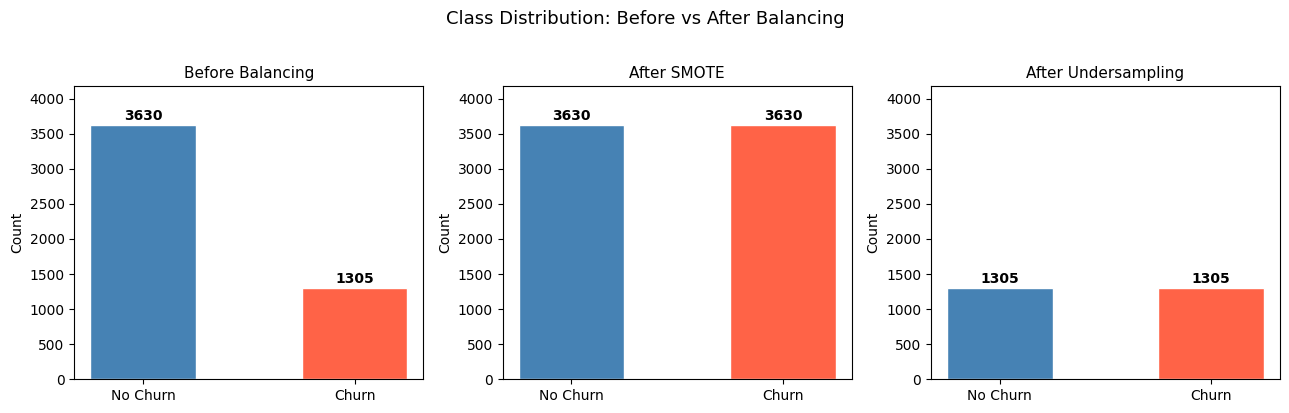

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

datasets_viz = [
    ('Before Balancing',     Counter(y_train)),
    ('After SMOTE',          Counter(y_train_smote)),
    ('After Undersampling',  Counter(y_train_under)),
]

for ax, (title, counter) in zip(axes, datasets_viz):
    vals = [counter[0], counter[1]]
    bars = ax.bar(['No Churn', 'Churn'], vals,
                  color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(Counter(y_train_smote)[0], Counter(y_train)[0]) * 1.15)

plt.suptitle('Class Distribution: Before vs After Balancing', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Performance Metrics — Before vs After

In [68]:
scaler_final  = StandardScaler()
X_tr_sc       = scaler_final.fit_transform(X_train_best)
X_te_sc       = scaler_final.transform(X_test_best)
X_smote_sc    = scaler_final.transform(X_train_smote)
X_under_sc    = scaler_final.transform(X_train_under)

balance_results = {}
datasets_eval = [
    ('Before (Original)',   X_tr_sc,    y_train),
    ('After SMOTE',         X_smote_sc, y_train_smote),
    ('After Undersampling', X_under_sc, y_train_under),
]

for name, X_tr, y_tr in datasets_eval:
    m = LogisticRegression(max_iter=5000, solver='saga', random_state=42)
    m.fit(X_tr, y_tr)
    y_pred  = m.predict(X_te_sc)
    y_proba = m.predict_proba(X_te_sc)[:, 1]
    balance_results[name] = {
        'model':     m,
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1 Score':  round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba), 4),
    }
    print(f"\n── {name} ──")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    print(f"ROC-AUC: {balance_results[name]['ROC-AUC']}")


── Before (Original) ──
              precision    recall  f1-score   support

    No Churn       0.83      0.92      0.87      1557
       Churn       0.69      0.49      0.57       559

    accuracy                           0.81      2116
   macro avg       0.76      0.70      0.72      2116
weighted avg       0.79      0.81      0.79      2116

ROC-AUC: 0.8496

── After SMOTE ──
              precision    recall  f1-score   support

    No Churn       0.91      0.75      0.82      1557
       Churn       0.53      0.79      0.63       559

    accuracy                           0.76      2116
   macro avg       0.72      0.77      0.73      2116
weighted avg       0.81      0.76      0.77      2116

ROC-AUC: 0.8513

── After Undersampling ──
              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.82      1557
       Churn       0.52      0.78      0.63       559

    accuracy                           0.75      2116
   macro avg       0.71  

## Summary — Metrics Comparison

=== Impact of Balancing — Backward (RFE) Features ===
                    Precision  Recall F1 Score ROC-AUC
Before (Original)      0.6859  0.4884   0.5705  0.8496
After SMOTE            0.5293  0.7925   0.6347  0.8513
After Undersampling    0.5222    0.78   0.6255  0.8485


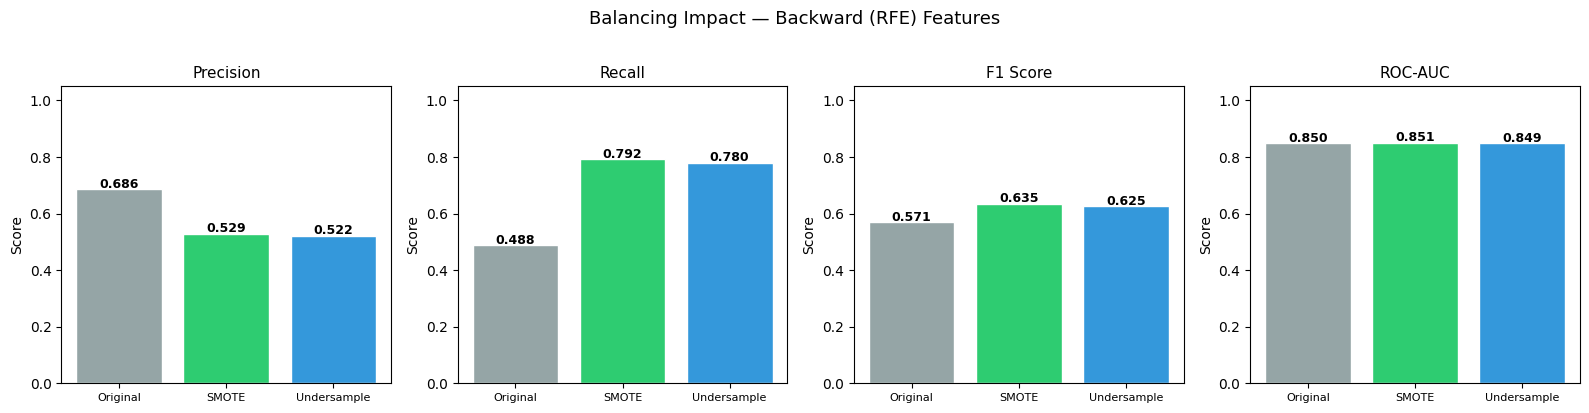

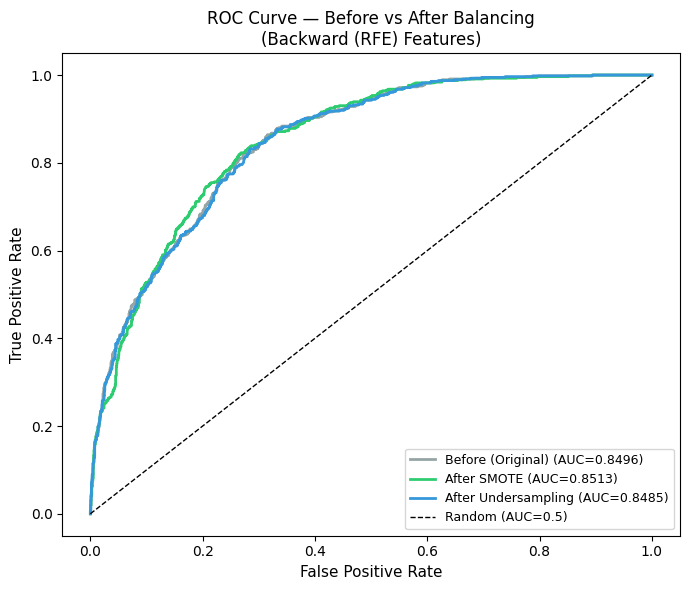

In [69]:
bal_summary = pd.DataFrame(balance_results).T.drop(columns=['model'])
print(f"=== Impact of Balancing — {best_method} Features ===")
print(bal_summary.to_string())

short   = ['Original', 'SMOTE', 'Undersample']
metrics = ['Precision', 'Recall', 'F1 Score', 'ROC-AUC']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, metric in zip(axes, metrics):
    vals = [balance_results[m][metric] for m in balance_results]
    bars = ax.bar(short, vals, color=colors, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(metric, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle(f'Balancing Impact — {best_method} Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

curve_data = [
    ('Before (Original)',   X_tr_sc,    y_train,       '#95a5a6'),
    ('After SMOTE',         X_smote_sc, y_train_smote, '#2ecc71'),
    ('After Undersampling', X_under_sc, y_train_under, '#3498db'),
]

fig, ax = plt.subplots(figsize=(7, 6))
for name, X_tr, y_tr, color in curve_data:
    m_plot = balance_results[name]['model']
    y_proba = m_plot.predict_proba(X_te_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = balance_results[name]['ROC-AUC']
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title(f'ROC Curve — Before vs After Balancing\n({best_method} Features)', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()




**FINAL EXPORT FOR DASH APP**

In [70]:
import os
import joblib
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, classification_report

# Create data folder if not exists
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

def save_if_not_exists(obj, filename, save_func):
    filepath = os.path.join(DATA_DIR, filename)
    
    if not os.path.exists(filepath):
        save_func(obj, filepath)
        print(f"Saved: {filepath}")
    else:
        print(f"Already exists: {filepath}")

# =========================
# Save Model & Preprocessing
# =========================
final_model = balance_results['After SMOTE']['model']

save_if_not_exists(final_model, 'model.pkl', joblib.dump)
save_if_not_exists(scaler_final, 'scaler.pkl', joblib.dump)
save_if_not_exists(best_features, 'features.pkl', joblib.dump)

# =========================
# Save dataset
# =========================
dataset_path = os.path.join(DATA_DIR, "final_dataset.csv")

if not os.path.exists(dataset_path):
    df.to_csv(dataset_path, index=False)
    print(f"Saved: {dataset_path}")
else:
    print(f"Already exists: {dataset_path}")

# =========================
# Feature Importance
# =========================
rf_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

save_if_not_exists(rf_imp, "rf_importance.csv", lambda obj, path: obj.to_csv(path, index=False))

# =========================
# Confusion Matrix
# =========================
cm_path = os.path.join(DATA_DIR, "confusion_matrix.csv")

if not os.path.exists(cm_path):
    y_pred = final_model.predict(X_te_sc)
    cm = confusion_matrix(y_test, y_pred)

    cm_df = pd.DataFrame(cm,
                         index=['Actual_No', 'Actual_Yes'],
                         columns=['Pred_No', 'Pred_Yes'])

    cm_df.to_csv(cm_path)
    print(f"Saved: {cm_path}")
else:
    print(f"Already exists: {cm_path}")

# =========================
# ROC Curve
# =========================
roc_path = os.path.join(DATA_DIR, "roc_curve.csv")

if not os.path.exists(roc_path):
    y_proba = final_model.predict_proba(X_te_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    roc_df = pd.DataFrame({
        'FPR': fpr,
        'TPR': tpr
    })

    roc_df.to_csv(roc_path, index=False)
    print(f"Saved: {roc_path}")
else:
    print(f"Already exists: {roc_path}")

# =========================
# Classification Report
# =========================
report_path = os.path.join(DATA_DIR, "classification_report.csv")

if not os.path.exists(report_path):
    y_pred = final_model.predict(X_te_sc)
    report = classification_report(y_test, y_pred, output_dict=True)

    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(report_path)

    print(f"Saved: {report_path}")
else:
    print(f"Already exists: {report_path}")

# =========================
# Summaries
# =========================
bal_summary = pd.DataFrame(balance_results).T.drop(columns=['model'])
save_if_not_exists(bal_summary, "balancing_summary.csv", lambda obj, path: obj.to_csv(path))

summary_df = pd.DataFrame(comparison_results).T.drop(columns=['features', 'scaler', 'model'])
save_if_not_exists(summary_df, "feature_selection_summary.csv", lambda obj, path: obj.to_csv(path))

print("Done ✅")

Saved: data\model.pkl
Saved: data\scaler.pkl
Saved: data\features.pkl
Saved: data\final_dataset.csv
Saved: data\rf_importance.csv
Saved: data\confusion_matrix.csv
Saved: data\roc_curve.csv
Saved: data\classification_report.csv
Saved: data\balancing_summary.csv
Saved: data\feature_selection_summary.csv
Done ✅
